## Question 1

### Question 1(1)

In [ ]:
with open("dante.txt" , "r", encoding="utf-8" ) as file:
    dante_line = file.readlines()
print(dante_line)

### Question 1(2)

In [5]:
dante_line_clean = [line.strip() for line in dante_line if line.strip() != ""]
print(dante_line_clean)

['Nel mezzo del cammin di nostra vita', 'mi ritrovai per una selva oscura,', 'ché la diritta via era smarrita.', 'Ahi quanto a dir qual era è cosa dura', 'esta selva selvaggia e aspra e forte', 'che nel pensier rinova la paura!']


### Question 1(3)

In [6]:
# Spell dante_lines_clean into a one-line string
dante_one_liner = " ".join(dante_line_clean)

#  Adding spaces after punctuation marks
for p in [".", ",", "!", "?", ":", ";"]:
    dante_one_liner = dante_one_liner.replace(p, p + "")

# Cleaning up extra spaces
dante_one_liner = " ".join(dante_one_liner.split())

print(dante_one_liner)


Nel mezzo del cammin di nostra vita mi ritrovai per una selva oscura, ché la diritta via era smarrita. Ahi quanto a dir qual era è cosa dura esta selva selvaggia e aspra e forte che nel pensier rinova la paura!


### Question 1(4)

In [10]:
remove_punctuation = lambda s: s[:-1] if s and s[-1] in [",", ".", "!"] else s

# test function
print(remove_punctuation("Hello"))
print(remove_punctuation("Hello class!"))

Hello
Hello class


### Question 1(5)

In [12]:
# Splitting clean lines into words
words = [remove_punctuation(word.lower())
         for line in dante_line_clean
         for word in line.split()]
print(words)

['nel', 'mezzo', 'del', 'cammin', 'di', 'nostra', 'vita', 'mi', 'ritrovai', 'per', 'una', 'selva', 'oscura', 'ché', 'la', 'diritta', 'via', 'era', 'smarrita', 'ahi', 'quanto', 'a', 'dir', 'qual', 'era', 'è', 'cosa', 'dura', 'esta', 'selva', 'selvaggia', 'e', 'aspra', 'e', 'forte', 'che', 'nel', 'pensier', 'rinova', 'la', 'paura']


### Question 1(6)

In [13]:
import collections
import unicodedata

# Remove the accent mark from the first letter of a word.
def remove_accent(char):
    return ''.join(
        c for c in unicodedata.normalize('NFD', char)
        if unicodedata.category(c) != 'Mn'
    )

# Create dictionaries
word_dict = collections.defaultdict(list)
for word in words:
    if word:
        first_letter = remove_accent(word[0])
        word_dict[first_letter].append(word)

print(dict(word_dict))

{'n': ['nel', 'nostra', 'nel'], 'm': ['mezzo', 'mi'], 'd': ['del', 'di', 'diritta', 'dir', 'dura'], 'c': ['cammin', 'ché', 'cosa', 'che'], 'v': ['vita', 'via'], 'r': ['ritrovai', 'rinova'], 'p': ['per', 'pensier', 'paura'], 'u': ['una'], 's': ['selva', 'smarrita', 'selva', 'selvaggia'], 'o': ['oscura'], 'l': ['la', 'la'], 'e': ['era', 'era', 'è', 'esta', 'e', 'e'], 'a': ['ahi', 'a', 'aspra'], 'q': ['quanto', 'qual'], 'f': ['forte']}


## Question 2

### Question 2(1)

In [3]:
import numpy as np

# Reading household income data
income = np.loadtxt("us_household_incomes.txt")

print(income[:10])

[ 53308. 102050. 192994.  46932.  43803.  53416. 536316.  42239.  24819.
 415819.]


### Question 2(2)

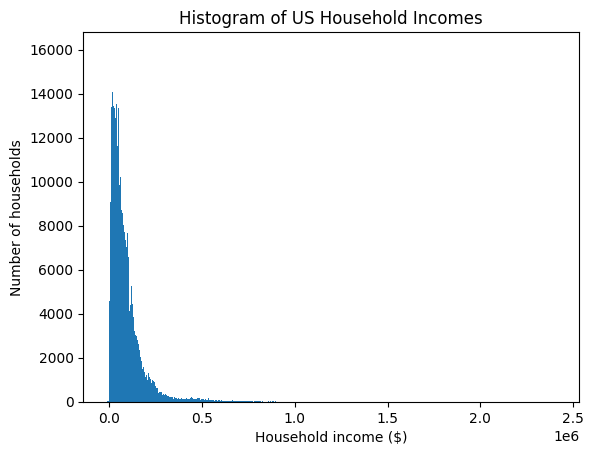

In [4]:
import matplotlib.pyplot as plt

# Draw a histogram
plt.hist(income,bins = "auto")
plt.xlabel("Household income ($)")
plt.ylabel("Number of households")
plt.title("Histogram of US Household Incomes")
plt.show()

The histogram of US household incomes is not normally distributed.
Instead, it is highly right-skewed: most households are concentrated at lower income levels, while a small number of households have extremely high incomes.

It is also not uniform, because the frequencies are not evenly spread across income ranges.

This skewness indicates that income inequality in the United States is relatively high, with most people earning modest incomes while a minority earn disproportionately high incomes

### Question 2(3)

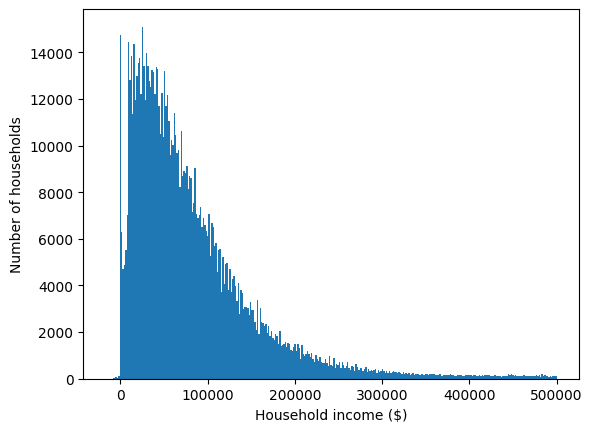

In [5]:
# Histogram limited to incomes < $500000
income_sub = income[income < 500000]

# Draw a histogram
plt.hist(income_sub,bins = "auto")
plt.xlabel("Household income ($)")
plt.ylabel("Number of households")
plt.show()

- After restricting to incomes < $500000, the histogram is still not uniform.
- It remains clearly right-skewed: most households cluster at lower incomes.
- Conclusion: income inequality persists even when high extremes are excluded.

### Question 2(4)

In [7]:
import numpy as np

# function of gini
def gini_np(y):
    y = np.asarray(y, dtype=float)
    total = y.sum()
    n = y.size
    if n == 0 or total == 0:
        return 0.0
    y_sorted = np.sort(y)
    i = np.arange(1, n + 1)
    return (2.0 * (i * y_sorted).sum() / (n * total)) - (n + 1.0) / n

# Poverty line ratio
poverty_line = 20000
ex4_share_below_poverty = np.mean(income < poverty_line)

# Gini coefficients (using ineqpy.gini)
ex4_gini = gini_np(income)

print("Share below $20000:", ex4_share_below_poverty)
print("Gini index:", ex4_gini)

Share below $20000: 0.14711442173300704
Gini index: 0.4810920394460463


About **14.7%** of households earn less than $20000 (poverty line).
The Gini coefficient is **≈0.48**, which indicates a relatively high level of income inequality in the United States.

### Question 2(5)

My estimate for the US Gini coefficient (0.48) is close to official values (0.47–0.49).
Compared internationally, the US shows higher inequality than most European countries (0.25–0.35), and is closer to Latin American countries such as Brazil (0.49).
It is still below the highest-inequality countries like South Africa (>0.60).

This matches expectations: the United States has relatively high income inequality compared to other developed nations.

### Question 2(6)

In [8]:
import numpy as np

# function of gini
def gini_np(y):
    y = np.asarray(y, dtype=float)
    n = y.size
    s = y.sum()
    if n == 0 or s == 0:
        return 0.0
    y_sorted = np.sort(y)
    i = np.arange(1, n + 1)
    return (2.0 * (i * y_sorted).sum() / (n * s)) - (n + 1.0) / n

# Baseline Gini
baseline_gini = gini_np(income)

# Policy A: +5000 per household < 40000
income_a = income.copy()
income_a[income_a < 40000] += 5000.0
ex6_gini_policy_a = gini_np(income_a)

# Policy B: +7000 per household < 30000
income_b = income.copy()
income_b[income_b < 30000] += 7000.0
ex6_gini_policy_b = gini_np(income_b)

# Which one has dropped more? --Whoever has the smaller Gini.
if ex6_gini_policy_a < ex6_gini_policy_b:
    ex6_gini_which_reduced_more = "Policy A"
else:
    ex6_gini_which_reduced_more = "Policy B"

# Add to dictionary
results = {}
results["ex6_gini_policy_a"] = ex6_gini_policy_a
results["ex6_gini_policy_b"] = ex6_gini_policy_b
results["ex6_gini_which_reduced_more"] = ex6_gini_which_reduced_more

# Print results
print(f"Baseline Gini: {baseline_gini:.4f}")
print(f"Policy A Gini: {ex6_gini_policy_a:.4f}")
print(f"Policy B Gini: {ex6_gini_policy_b:.4f}")
print("Which reduced inequality more:", ex6_gini_which_reduced_more)


Baseline Gini: 0.4811
Policy A Gini: 0.4602
Policy B Gini: 0.4583
Which reduced inequality more: Policy B


Baseline Gini was about 0.48.
Both policies reduced inequality, but Policy B lowered the Gini more (≈0.458 vs. ≈0.460).
So Policy B is more effective.

### Question 2(7)

In [9]:
# Policy C: 5 % tax for households with income >250000

# Copy income to avoid overwriting original data
income_c = income.copy()
mark_c = income_c > 250000
income_c[mark_c] *= 0.95

# Calculate the new Gini coefficient
ex7_gini_policy_c = gini_np(income_c)

# Add to dictionary
results["ex7_gini_policy_c"] = ex7_gini_policy_c

# Print results
print(f"Policy C Gini: {ex7_gini_policy_c:.4f}")

Policy C Gini: 0.4756


After applying Policy C (5% tax on incomes > $250000),
the Gini coefficient decreases slightly, showing a small reduction in inequality.
The new value is stored in ex7_gini_policy_c

### Question 2(8)

In [10]:
import numpy as np

# Calculation of total tax: 5% for all households with income >250000
high_mask = income > 250000
ex8_revenue_raised = 0.05 * np.sum(income[high_mask])

# Estimating the national true total
ex8_revenue_raised_national_est = 137 * ex8_revenue_raised

# save results
results["ex8_revenue_raised"] = ex8_revenue_raised

# print results
print(f"Revenue raised: ${ex8_revenue_raised:,.2f}")
print(f"National estimate: ${ex8_revenue_raised_national_est:,.2f}")


Revenue raised: $929,623,340.85
National estimate: $127,358,397,696.45


The 5% tax on incomes > 250000 raises about 929 million in the sample,
or roughly $127 billion nationwide.

### Question 2(9)

In [11]:
# Identify the number of households with incomes < 30000
low_income_mask = income < 30000
num_low_income_households = np.sum(low_income_mask)

# Calculation of average transfer amounts
ex9_transfers = ex8_revenue_raised / num_low_income_households

# save results
results["ex9_transfers"] = ex9_transfers

# print
print("Number of households less $30000:", num_low_income_households)
print(f"Transfer per household: ${ex9_transfers:,.2f}")

Number of households less $30000: 220906
Transfer per household: $4,208.23


There are 220,906 households below 30000.
Each would get about $4208 from the tax revenue.

### Question 2(10)

In [12]:
# Copy income to avoid modifying original
income_d = income.copy()

# 5 % tax on households with income > 250000
mask_high = income_d > 250000
income_d[mask_high] *= 0.95

# Subsidies for families with incomes < 30,000
mask_low = income_d < 30000
income_d[mask_low] += ex9_transfers

# Calculate the new Gini
ex10_gini_policy_d = gini_np(income_d)

# save results
results["ex10_gini_policy_d"] = ex10_gini_policy_d

# print
print(f"Policy D Gini: {ex10_gini_policy_d:.4f}")

Policy D Gini: 0.4617


Policy D lowers the Gini to about 0.462,
a modest reduction in inequality compared to the baseline (0.481).

### Question 2(11)

In [13]:
# Copy income to avoid modifying original
income_e = income.copy()

# 5 % tax on households with income > 250000
mask_high = income_e > 250000
income_e[mask_high] *= 0.95

# Number of households with income < 40,000 found
mask_low_40k = income_e < 40000
num_low_40k = np.sum(mask_low_40k)

# Calculation of average subsidy per household
transfer_per_household_e = ex8_revenue_raised / num_low_40k

# Subsidies for families with incomes < 40,000
income_e[mask_low_40k] += transfer_per_household_e

# Calculate the new Gini
ex11_gini_policy_e = gini_np(income_e)

# Save results
results["ex11_gini_policy_e"] = ex11_gini_policy_e

# Print
print(f"Policy E Gini: {ex11_gini_policy_e:.4f}")

Policy E Gini: 0.4626


Policy E reduces inequality (Gini ≈ 0.463),
but not as much as Policy D (Gini ≈ 0.462).

### Question 2(12)

In [14]:
# Comparison of Policy D and Policy E's Gini
if ex10_gini_policy_d < ex11_gini_policy_e:
    ex12_policy_recommendation = "Policy D"
else:
    ex12_policy_recommendation = "Policy E"

# save results
results["ex12_policy_recommendation"] = ex12_policy_recommendation
print("Policy recommendation:", ex12_policy_recommendation)

Policy recommendation: Policy D


Policy D (0.4617) reduces inequality more than Policy E (0.4626).
Therefore, the recommendation is Policy D.

## Question 3

### Question 3(1)

In [15]:
import pandas as pd

# GDP per capita
gdppercap = pd.Series( [34605, 34493, 12393, 44200, 10041, 58138, 4709, 49284,
10109, 42536], index=[ "Bahrain", "Belgium", "Bulgaria", "Ireland", "Macedonia",
"Norway", "Paraguay", "Singapore", "South Africa", "Switzerland", ], )

# Print Series
print(gdppercap)

Bahrain         34605
Belgium         34493
Bulgaria        12393
Ireland         44200
Macedonia       10041
Norway          58138
Paraguay         4709
Singapore       49284
South Africa    10109
Switzerland     42536
dtype: int64


### Question 3(2)

In [16]:
# mean
mean_gdp = gdppercap.mean()

# median
median_gdp = gdppercap.median()

# minimum
min_gdp = gdppercap.min()

# maximum
max_gdp = gdppercap.max()

# print
print("Mean GDP per capita:", mean_gdp)
print("Median GDP per capita:", median_gdp)
print("Minimum GDP per capita:", min_gdp)
print("Maximum GDP per capita:", max_gdp)

Mean GDP per capita: 30050.8
Median GDP per capita: 34549.0
Minimum GDP per capita: 4709
Maximum GDP per capita: 58138


### Question 3(3)

In [17]:
# Find the country with the largest and smallest GDP
ex3_highest_gdp_percap = gdppercap.idxmax()
ex3_lowest_gdp_percap = gdppercap.idxmin()

# Save results
results[ex3_highest_gdp_percap] = ex3_lowest_gdp_percap
results[ex3_lowest_gdp_percap] = ex3_highest_gdp_percap

# Print results
print("Country with highest GDP per capita:", ex3_highest_gdp_percap)
print("Country with lowest GDP per capita:", ex3_lowest_gdp_percap)

Country with highest GDP per capita: Norway
Country with lowest GDP per capita: Paraguay


### Question 3(4)

In [18]:
# Identify countries with GDP < 20000
lessthan_20000 = gdppercap[gdppercap < 20000].index.tolist()

# arrange in order
ex4_lessthan_20000 = sorted(lessthan_20000)

# Save results
results["ex4_lessthan_20000"] = ex4_lessthan_20000

# Print
print("Countries with GDP per capita < $20000:", ex4_lessthan_20000)

Countries with GDP per capita < $20000: ['Bulgaria', 'Macedonia', 'Paraguay', 'South Africa']


### Question 3(5)

In [19]:
# Take out Switzerland's GDP per capita
ex5_switzerland = gdppercap["Switzerland"]

# Save results
results["ex5_switzerland"] = ex5_switzerland

# Print
print("GDP per capita of Switzerland:", ex5_switzerland)

GDP per capita of Switzerland: 42536


### Question 3(6)

In [20]:
import numpy as np

def gini_loop(series):
    y = list(np.asarray(series, dtype = float))
    y.sort()
    n = len(y)
    s = sum(y)
    if n == 0 or s == 0:
        return 0.0
    weighted = 0.0
    i = 1
    for yi in y:
        weighted += i * yi
        i += 1

    return (2.0 * weighted) / (n * s) - (n + 1.0) / n

# Calculate and save
ex6_gini_loop = gini_loop(gdppercap)
results["ex6_gini_loop"] = ex6_gini_loop

# Print
print(f"Gini (loop, GDP per capita): {ex6_gini_loop:.4f}")


Gini (loop, GDP per capita): 0.3383


### Question 3(7)

In [21]:
import numpy as np

def gini_vectorized(series):
    y = np.asarray(series, dtype=float)
    n = y.size
    s = y.sum()
    if n == 0 or s == 0:
        return 0.0
    y_sorted = np.sort(y)
    i = np.arange(1, n + 1, dtype=float)
    return (2.0 * (i * y_sorted).sum() / (n * s)) - (n + 1.0) / n

# Calculate and save
ex7_gini_vectorized = gini_vectorized(gdppercap)
results["ex7_gini_vectorized"] = ex7_gini_vectorized

# Print
print(f"Gini (vectorized, GDP per capita): {ex7_gini_vectorized:.4f}")

Gini (vectorized, GDP per capita): 0.3383


### Question 3(8)

In [22]:
avg_growth = pd.Series( [ -0.29768835, 0.980299584, 4.52991925, 3.686556736,
2.621416804, 0.775132075, 2.015489468, 3.345793635, 1.349993318, 0.982775018,
], index=[ "Bahrain", "Belgium", "Bulgaria", "Ireland", "Macedonia", "Norway",
"Paraguay", "Singapore", "South Africa", "Switzerland", ], )

# timing difference
t = 17

# Calculation of GDP per capita in 2025
gdp_2025 = gdppercap * (1 + avg_growth/100) ** t

# Calculating Gini coefficients with vectorised gini functions
ex8_gini_2025 = gini_vectorized(gdp_2025)

# Save results
results["ex8_gini_2025"] = ex8_gini_2025

# Print
print("GDP per capita in 2025 (estimated):")
print(gdp_2025.round(2))
print(f"\nEstimated Gini in 2025: {ex8_gini_2025:.4f}")

GDP per capita in 2025 (estimated):
Bahrain         32894.84
Belgium         40714.97
Bulgaria        26318.85
Ireland         81790.71
Macedonia       15589.17
Norway          66292.97
Paraguay         6610.78
Singapore       86235.01
South Africa    12697.30
Switzerland     50229.72
dtype: float64

Estimated Gini in 2025: 0.3656


Gini rises from 0.338 (2008) to 0.366 (2025),
showing higher inequality across countries.

### Question 3(9)

Since the Gini increased from 0.338 to 0.366,
the result suggests no convergence.
Inequality rose, meaning richer countries pulled further ahead